In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

In [16]:
import torch 

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
from agent import AgentMLP , AgentCNN
from environment import  snake_environment

In [4]:
snake_env1=snake_environment(5,5)

In [5]:
state=snake_env1.get_state()
state.shape

torch.Size([5, 5, 4])

In [7]:
snake_env1.render()
snake_env1.step(0)

_ F _ _ _
_ _ _ _ _
_ O _ _ _
_ X _ _ _
_ _ _ _ _


(tensor([[[1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.]],
 
         [[0., 0., 1., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [0., 0., 0., 1.],
          [0., 1., 0., 0.]],
 
         [[1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.]],
 
         [[1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.]],
 
         [[1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.]]]),
 -0.01,
 False)

In [8]:
hidden_size=2048
snake_agent1=AgentMLP(snake_env1.d_model*snake_env1.width*snake_env1.height,hidden_size)



#snake_agent1 training
score_log=[]
score_mean_log=[]
batch=500
render_every=1000
num_games=10000
batch_size=500
update_target_every=500


for epoch in range(num_games+1):
    score=snake_env1.snake.score
    snake_env1.reset()
    if (epoch + 1) % update_target_every == 0:
        snake_agent1.update_target_model()

        
    if   epoch>100 and epoch%render_every==0:
        print(f"GAME NUMBER {epoch}")
        
        original_epsilon = snake_agent1.epsilon
        snake_agent1.epsilon = 0
        
        while not snake_env1.gameover : 
            state=snake_env1.get_state()
            state=state.flatten()
            action=snake_agent1.get_action(state)
            next_state , reward , done =snake_env1.step(action)
            next_state=next_state.flatten()
            snake_env1.render()
            print("===================")
        snake_agent1.epsilon = original_epsilon
    else:
        while not snake_env1.gameover :
            state=snake_env1.get_state()
            state=state.flatten()
            action=snake_agent1.get_action(state)
            next_state , reward , done =snake_env1.step(action)
            next_state=next_state.flatten()
            snake_agent1.remember(state,action,reward,next_state,done)
            snake_agent1.replay(batch_size)
    
    score_log.append(score)
    print(f"score for game {epoch}: {score}")
    if (epoch + 1)%batch==0:
        mean=sum(score_log)/len(score_log)
        score_mean_log.append(mean)
        score_log=[]

plt.figure(figsize=(12, 6))
plt.plot(score_mean_log, label='score mean')
plt.xlabel(f'Batch of {batch} Games')
plt.ylabel(f'average score')
plt.grid(True)
plt.show()

    


In [9]:
state_dict = torch.load("models/qNetwork.pth", weights_only=True,map_location=torch.device(device))
snake_agent1.model.load_state_dict(state_dict)

<All keys matched successfully>

In [13]:
#snake_agent1 deployment

num_games=1
snake_agent1.epsilon = 0

for epoch in range(num_games):
    snake_env1.reset()
    print(f"GAME NUMBER {epoch}")

    while not snake_env1.gameover : 
        state=snake_env1.get_state()
        state=state.flatten()
        
        action=snake_agent1.get_action(state)
        next_state , reward , done =snake_env1.step(action)
        snake_env1.render()
    score=snake_env1.snake.score
    print(f"score for game {epoch}: {score}")

    


GAME NUMBER 0
_ _ _ _ _
_ _ _ X _
_ F _ O _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ X O _
_ F _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ X O _ _
_ F _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ O O _ _
_ X _ _ _
_ F _ _ _
_ _ _ _ _
_ F _ _ _
_ O O _ _
_ O _ _ _
_ X _ _ _
_ _ _ _ _
_ F _ _ _
_ O _ _ _
_ O _ _ _
X O _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
X O _ _ _
O O _ _ _
_ _ _ _ _
_ F _ _ _
X _ _ _ _
O _ _ _ _
O O _ _ _
_ _ _ _ _
X F _ _ _
O _ _ _ _
O _ _ _ _
O _ _ _ _
_ _ _ _ _
O X F _ _
O _ _ _ _
O _ _ _ _
O _ _ _ _
_ _ _ _ _
O O X _ _
O F _ _ _
O _ _ _ _
O _ _ _ _
_ _ _ _ _
O O O X _
O F _ _ _
O _ _ _ _
_ _ _ _ _
_ _ _ _ _
O O O O _
O F _ X _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O O O O _
_ F _ O _
_ _ _ X _
_ _ _ _ _
_ _ _ _ _
_ O O O _
_ F _ O _
_ _ _ O _
_ _ _ X _
_ _ _ _ _
_ _ O O _
_ F _ O _
_ _ _ O _
_ _ _ O _
_ _ _ X _
_ _ _ O _
_ F _ O _
_ _ _ O _
_ _ _ O _
_ _ X O _
_ _ _ _ _
_ F _ O _
_ _ _ O _
_ _ _ O _
_ X O O _
_ _ _ _ _
_ F _ _ _
_ _ _ O _
_ X _ O _
_ O O O _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
X O _ 

In [16]:
snake_agent2=AgentCNN(snake_env1.d_model,snake_env1.width,snake_env1.height,hidden_size=556)

/home/wadhah.zai/.conda/envs/isaaclab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


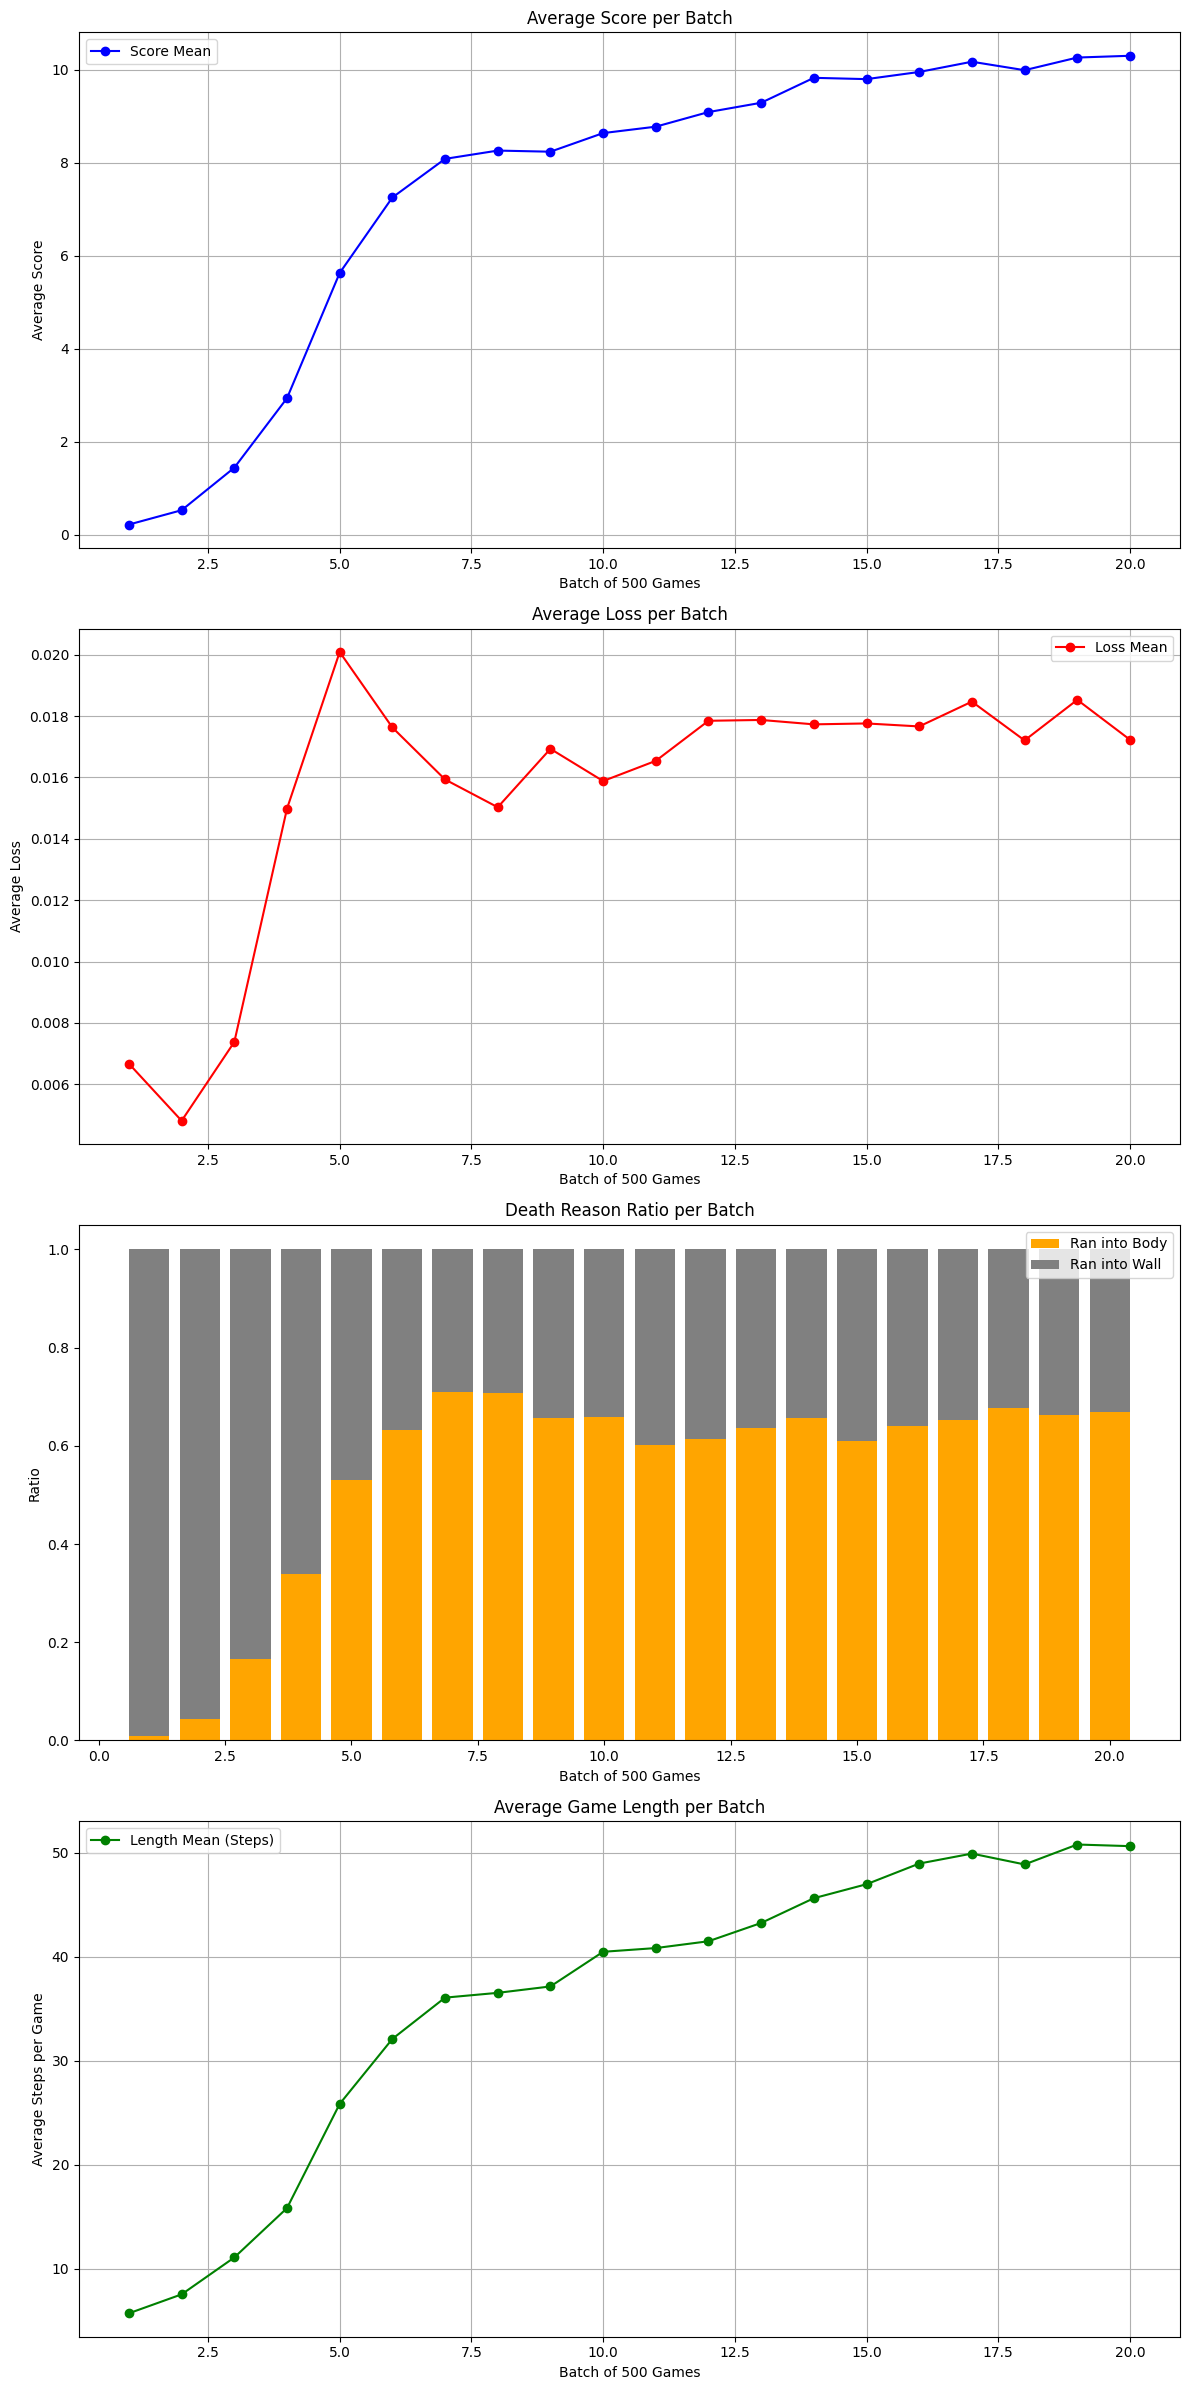

Training Games:   5%|▌         | 509/10001 [00:04<03:06, 51.02game/s, score=0, best=3, steps=3, eps=0.780]  

Batch 500 | Avg Score: 0.220 | Avg Loss: 0.0067 | Avg Length: 5.7


Training Games:  10%|█         | 1008/10001 [00:10<04:27, 33.65game/s, score=1, best=4, steps=5, eps=0.538] 

Batch 1000 | Avg Score: 0.528 | Avg Loss: 0.0048 | Avg Length: 7.5
_ O X _ _
_ _ _ _ _
_ _ F _ _
_ _ _ _ _
_ _ _ _ _
/////////
_ _ O _ _
_ _ X _ _
_ _ F _ _
_ _ _ _ _
_ _ _ _ _
/////////
_ _ O _ _
_ _ O _ _
_ _ X _ _
_ _ _ F _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ O _ _
_ _ O _ _
_ _ X F _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ O _ _
_ _ O F _
_ _ O X _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ O _ _
_ _ O X _
_ _ O O _
_ _ _ _ F
/////////
_ _ _ _ _
_ _ _ _ _
_ _ O O X
_ _ O O _
_ _ _ _ F
/////////
_ _ _ _ _
_ _ _ _ X
_ _ _ O O
_ _ O O _
_ _ _ _ F
/////////
_ _ _ _ _
_ _ _ X O
_ _ _ O O
_ _ _ O _
_ _ _ _ F
/////////
_ _ _ X _
_ _ _ O O
_ _ _ O O
_ _ _ _ _
_ _ _ _ F
/////////
_ _ _ O X
_ _ _ O O
_ _ _ _ O
_ _ _ _ _
_ _ _ _ F
/////////
_ _ _ O X
_ _ _ O O
_ _ _ _ O
_ _ _ _ _
_ _ _ _ F
/////////


Training Games:  15%|█▌        | 1508/10001 [00:19<05:13, 27.11game/s, score=2, best=8, steps=25, eps=0.294]

...

Batch 9000 | Avg Score: 9.986 | Avg Loss: 0.0172 | Avg Length: 48.9
F _ _ _ _
X O _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
/////////
X _ _ _ _
O O _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
/////////
O X _ _ _
O _ _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
/////////
O O _ _ _
_ X _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
/////////
_ O _ _ _
_ O _ _ _
_ X _ _ _
_ F _ _ _
_ _ _ _ _
/////////
_ O _ _ _
_ O _ _ _
_ O F _ _
_ X _ _ _
_ _ _ _ _
/////////
_ _ _ _ _
_ O _ _ _
_ O F _ _
_ O X _ _
_ _ _ _ _
/////////
F _ _ _ _
_ O _ _ _
_ O X _ _
_ O O _ _
_ _ _ _ _
/////////
F _ _ _ _
_ _ X _ _
_ O O _ _
_ O O _ _
_ _ _ _ _
/////////
F _ _ _ _
_ X O _ _
_ _ O _ _
_ O O _ _
_ _ _ _ _
/////////
F X _ _ _
_ O O _ _
_ _ O _ _
_ _ O _ _
_ _ _ _ _
/////////
X O _ _ _
_ O O _ _
_ F O _ _
_ _ O _ _
_ _ _ _ _
/////////
O O _ _ _
X O O _ _
_ F O _ _
_ _ _ _ _
_ _ _ _ _
/////////
O O _ _ _
O O O _ _
X F _ _ _
_ _ _ _ _
_ _ _ _ _
/////////
O O _ _ _
O O O _ _
O X _ _ _
_ F _ _ _
_ _ _ _ _
/////////
O O _ _ _
O O _ _ _
O O X _ _
_ 

Training Games:  95%|█████████▌| 9501/10001 [11:27<01:35,  5.24game/s, score=15, best=18, steps=57, eps=0.000] 

Batch 9500 | Avg Score: 10.258 | Avg Loss: 0.0185 | Avg Length: 50.8


Training Games: 100%|██████████| 10001/10001 [12:19<00:00, 13.53game/s, score=4, best=18, steps=19, eps=0.000] 


Batch 10000 | Avg Score: 10.296 | Avg Loss: 0.0172 | Avg Length: 50.6
F X O _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
/////////
X O O _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ F _
_ _ _ _ _
/////////
O O _ _ _
X _ _ _ _
_ _ _ _ _
_ _ _ F _
_ _ _ _ _
/////////
O _ _ _ _
O _ _ _ _
X _ _ _ _
_ _ _ F _
_ _ _ _ _
/////////
_ _ _ _ _
O _ _ _ _
O X _ _ _
_ _ _ F _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ _ _ _
O O X _ _
_ _ _ F _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ _ _ _
_ O O X _
_ _ _ F _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ F _ _
_ O O O _
_ _ _ X _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ F _ _
_ _ O O _
_ _ X O _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ F _ _
_ _ _ O _
_ X O O _
_ _ _ _ _
/////////
_ _ _ _ _
_ _ F _ _
_ X _ _ _
_ O O O _
_ _ _ _ _
/////////
_ _ _ _ _
_ X F _ _
_ O _ _ _
_ O O _ _
_ _ _ _ _
/////////
_ _ _ _ F
_ O X _ _
_ O _ _ _
_ O O _ _
_ _ _ _ _
/////////
_ _ _ _ F
_ O O X _
_ O _ _ _
_ O _ _ _
_ _ _ _ _
/////////
_ _ _ _ F
_ O O O X
_ O _ _ _
_ _ _ _ _
_ _ _ _ _
/////////
_ _ _ _ X
_ O O O O
_ O _ F _


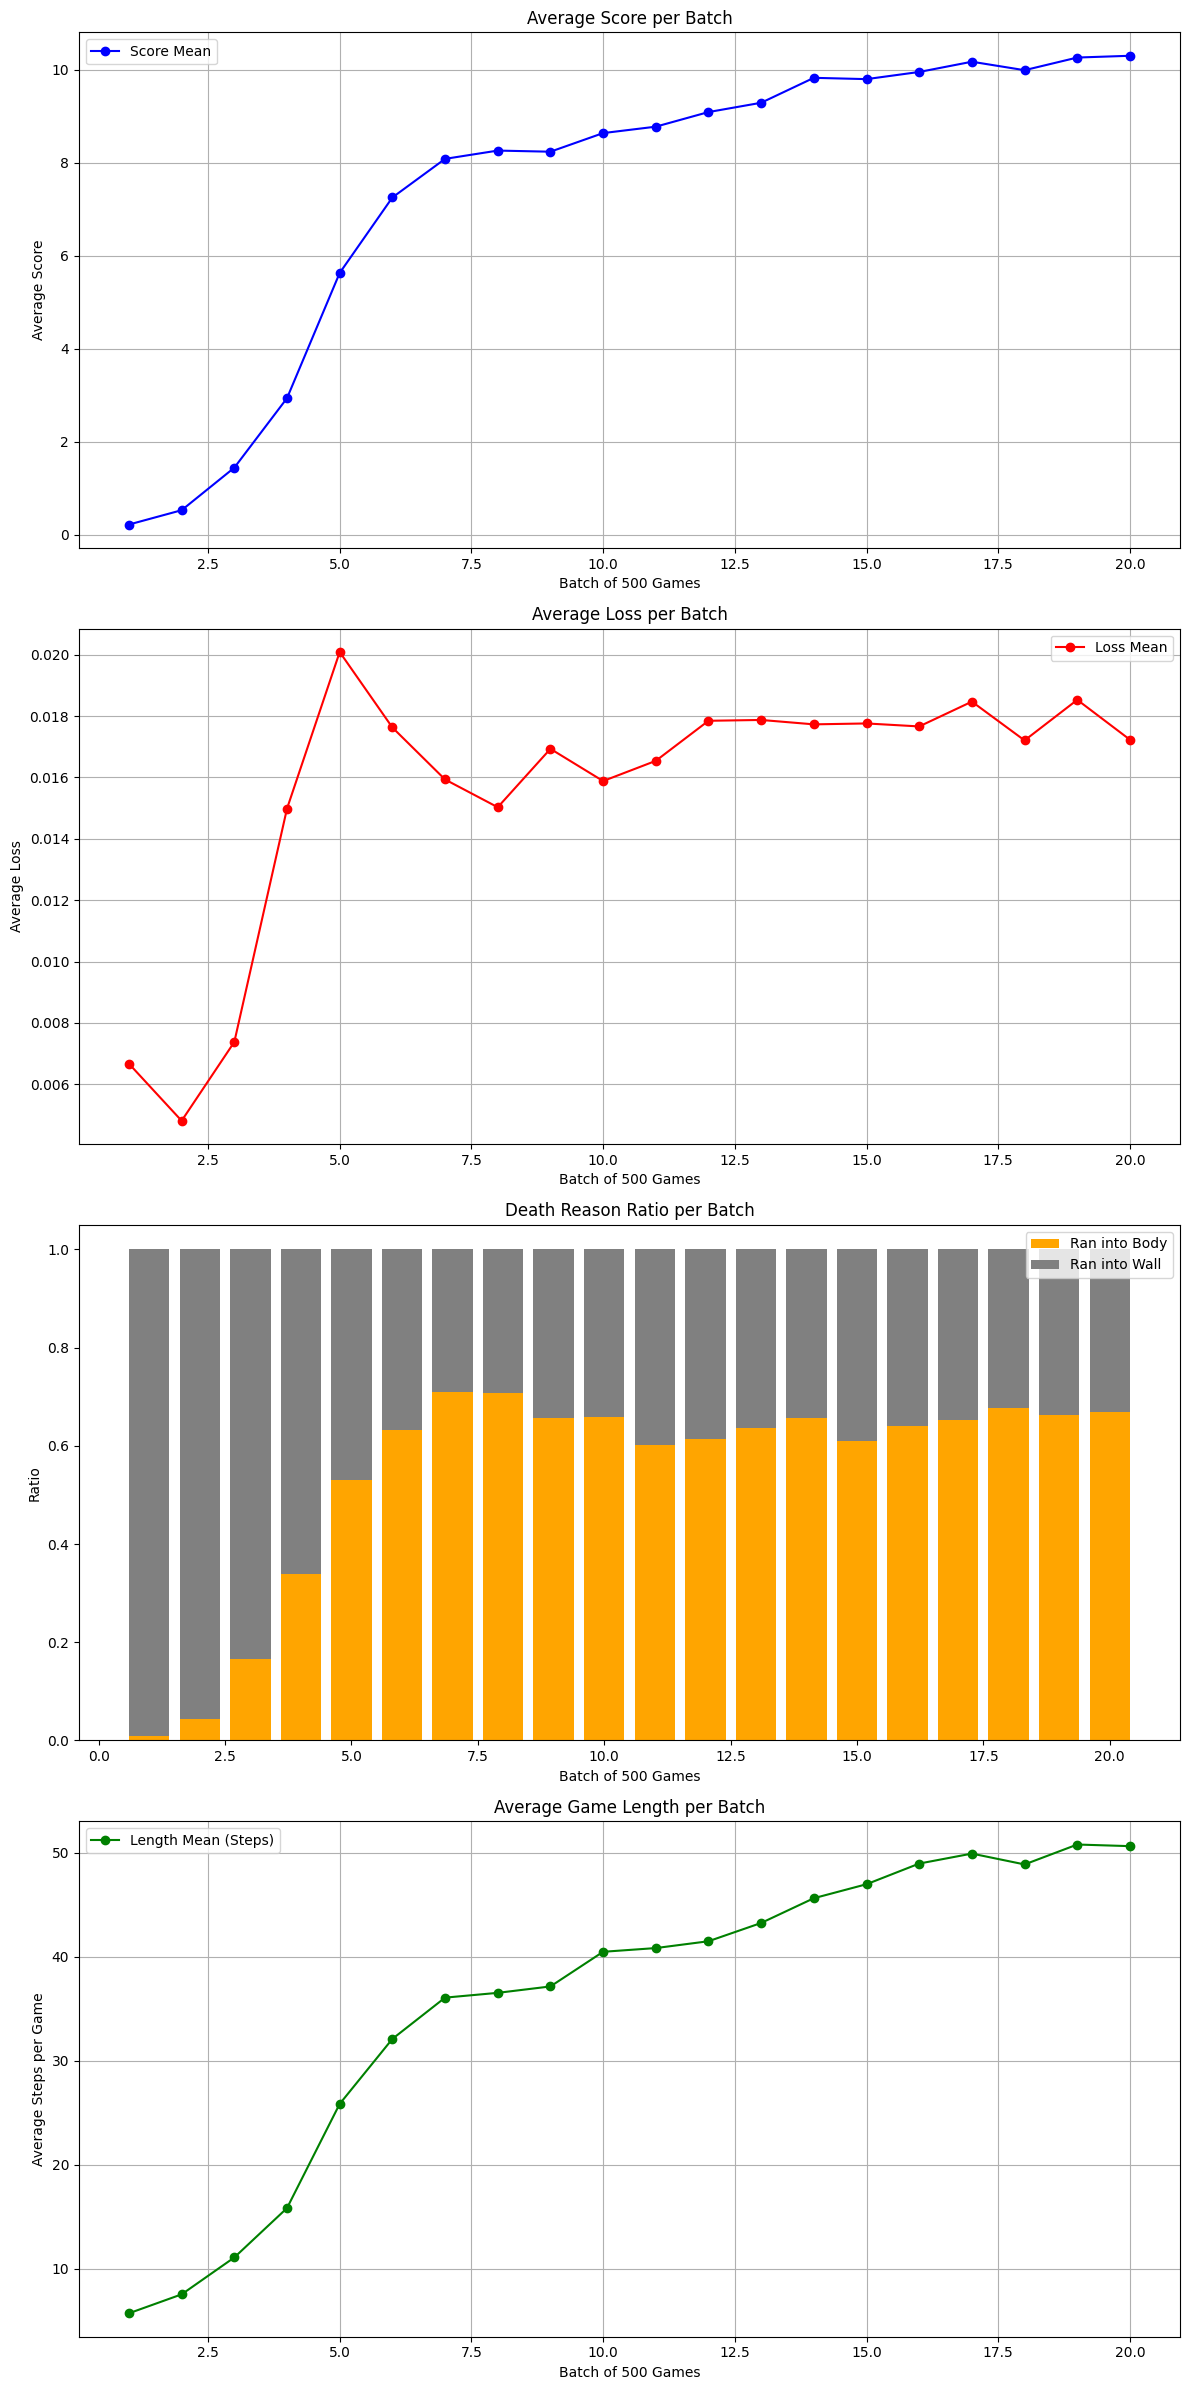

In [ ]:
# Existing Hyperparameters
score_log = []
score_mean_log = []
logging_batch = 500
render_every = 1000
num_games = 10000
batch_size = 256
update_target_every = 512

# Tracking Variables
best_score = -1
loss_log = []
loss_mean_log = []
death_body_count = 0
death_wall_count = 0
death_ratio_log = []

# New Tracking Variables for Game Length
length_log = []
length_mean_log = []

# Create a live figure that will be updated during training.
plt.ion()
fig, axs = plt.subplots(4, 1, figsize=(12, 24))
live_display = display(fig, display_id=True)

score_line, = axs[0].plot([], [], label='Score Mean', color='blue', marker='o')
loss_line, = axs[1].plot([], [], label='Loss Mean', color='red', marker='o')
length_line, = axs[3].plot([], [], label='Length Mean (Steps)', color='green', marker='o')

axs[0].set_title('Average Score per Batch')
axs[0].set_xlabel(f'Batch of {logging_batch} Games')
axs[0].set_ylabel('Average Score')
axs[0].grid(True)
axs[0].legend()

axs[1].set_title('Average Loss per Batch')
axs[1].set_xlabel(f'Batch of {logging_batch} Games')
axs[1].set_ylabel('Average Loss')
axs[1].grid(True)
axs[1].legend()

axs[2].set_title('Death Reason Ratio per Batch')
axs[2].set_xlabel(f'Batch of {logging_batch} Games')
axs[2].set_ylabel('Ratio')

axs[3].set_title('Average Game Length per Batch')
axs[3].set_xlabel(f'Batch of {logging_batch} Games')
axs[3].set_ylabel('Average Steps per Game')
axs[3].grid(True)
axs[3].legend()


def update_live_plots():
    batches = list(range(1, len(score_mean_log) + 1))

    score_line.set_data(batches, score_mean_log)
    axs[0].relim()
    axs[0].autoscale_view()

    loss_line.set_data(batches, loss_mean_log)
    axs[1].relim()
    axs[1].autoscale_view()

    length_line.set_data(batches, length_mean_log)
    axs[3].relim()
    axs[3].autoscale_view()

    body_ratios = [r[0] for r in death_ratio_log]
    wall_ratios = [r[1] for r in death_ratio_log]
    axs[2].cla()
    axs[2].bar(batches, body_ratios, label='Ran into Body', color='orange')
    axs[2].bar(batches, wall_ratios, bottom=body_ratios, label='Ran into Wall', color='gray')
    axs[2].set_title('Death Reason Ratio per Batch')
    axs[2].set_xlabel(f'Batch of {logging_batch} Games')
    axs[2].set_ylabel('Ratio')
    axs[2].legend()

    fig.tight_layout()
    live_display.update(fig)


progress_bar = tqdm(range(num_games + 1), desc="Training Games", unit="game")

for epoch in progress_bar:
    snake_env1.reset()
    game_steps = 0

    # Update target model periodically.
    if (epoch + 1) % update_target_every == 0:
        snake_agent2.update_target_model()

    # Render evaluation game occasionally with greedy policy.
    if epoch > 100 and epoch % render_every == 0:
        original_epsilon = snake_agent2.epsilon
        snake_agent2.epsilon = 0

        while not snake_env1.gameover:
            state = snake_env1.get_state()
            action = snake_agent2.get_action(state.unsqueeze(0))
            next_state, reward, done = snake_env1.step(action)
            snake_env1.render()
            game_steps += 1

        snake_agent2.epsilon = original_epsilon
        game_loss = None

    # Train normally.
    else:
        game_loss = 0.0
        while not snake_env1.gameover:
            state = snake_env1.get_state()
            action = snake_agent2.get_action(state.unsqueeze(0))
            next_state, reward, done = snake_env1.step(action)
            snake_agent2.remember(state, action, reward, next_state, done)
            game_steps += 1

            if game_steps % 4 == 0:
                loss = snake_agent2.replay(batch_size)
                if loss is not None:
                    game_loss += loss

        if game_steps > 0:
            loss_log.append(game_loss / game_steps)

    score = snake_env1.snake.score

    if score > best_score and epoch > 0:
        best_score = score

    if hasattr(snake_env1, 'death_reason'):
        if snake_env1.death_reason == 'wall':
            death_wall_count += 1
        elif snake_env1.death_reason == 'body':
            death_body_count += 1

    score_log.append(score)
    length_log.append(game_steps)

    progress_bar.set_postfix({
        "score": score,
        "best": best_score if best_score >= 0 else "-",
        "steps": game_steps,
        "eps": f"{snake_agent2.epsilon:.3f}"
    })

    # Logging batch updates.
    if (epoch + 1) % logging_batch == 0:
        mean = sum(score_log) / len(score_log)
        score_mean_log.append(mean)
        score_log = []

        if loss_log:
            loss_mean = sum(loss_log) / len(loss_log)
            loss_mean_log.append(loss_mean)
            loss_log = []
        else:
            loss_mean_log.append(0)

        if length_log:
            length_mean = sum(length_log) / len(length_log)
            length_mean_log.append(length_mean)
            length_log = []
        else:
            length_mean_log.append(0)

        total_deaths = death_body_count + death_wall_count
        if total_deaths > 0:
            death_ratio_log.append((death_body_count / total_deaths, death_wall_count / total_deaths))
        else:
            death_ratio_log.append((0, 0))

        death_body_count = 0
        death_wall_count = 0

        update_live_plots()

        tqdm.write(
            f"Batch {epoch + 1} | Avg Score: {score_mean_log[-1]:.3f} | "
            f"Avg Loss: {loss_mean_log[-1]:.4f} | Avg Length: {length_mean_log[-1]:.1f}"
        )

# Keep final figure visible after training ends.
plt.ioff()
fig.tight_layout()
live_display.update(fig)
plt.show()

In [ ]:
#SAVE MODEL
torch.save(snake_agent2.model.state_dict(), "agent2_cnn.pth")


In [26]:
#testing agents:
env=snake_environment(5,5)
agent=AgentCNN(snake_env1.d_model,snake_env1.width,snake_env1.height,hidden_size=556)

state_dict = torch.load(
    "models/agent2_cnn.pth", weights_only=True, map_location=torch.device(device)
)
agent.model.load_state_dict(state_dict)

#exploit:
agent.epsilon=0

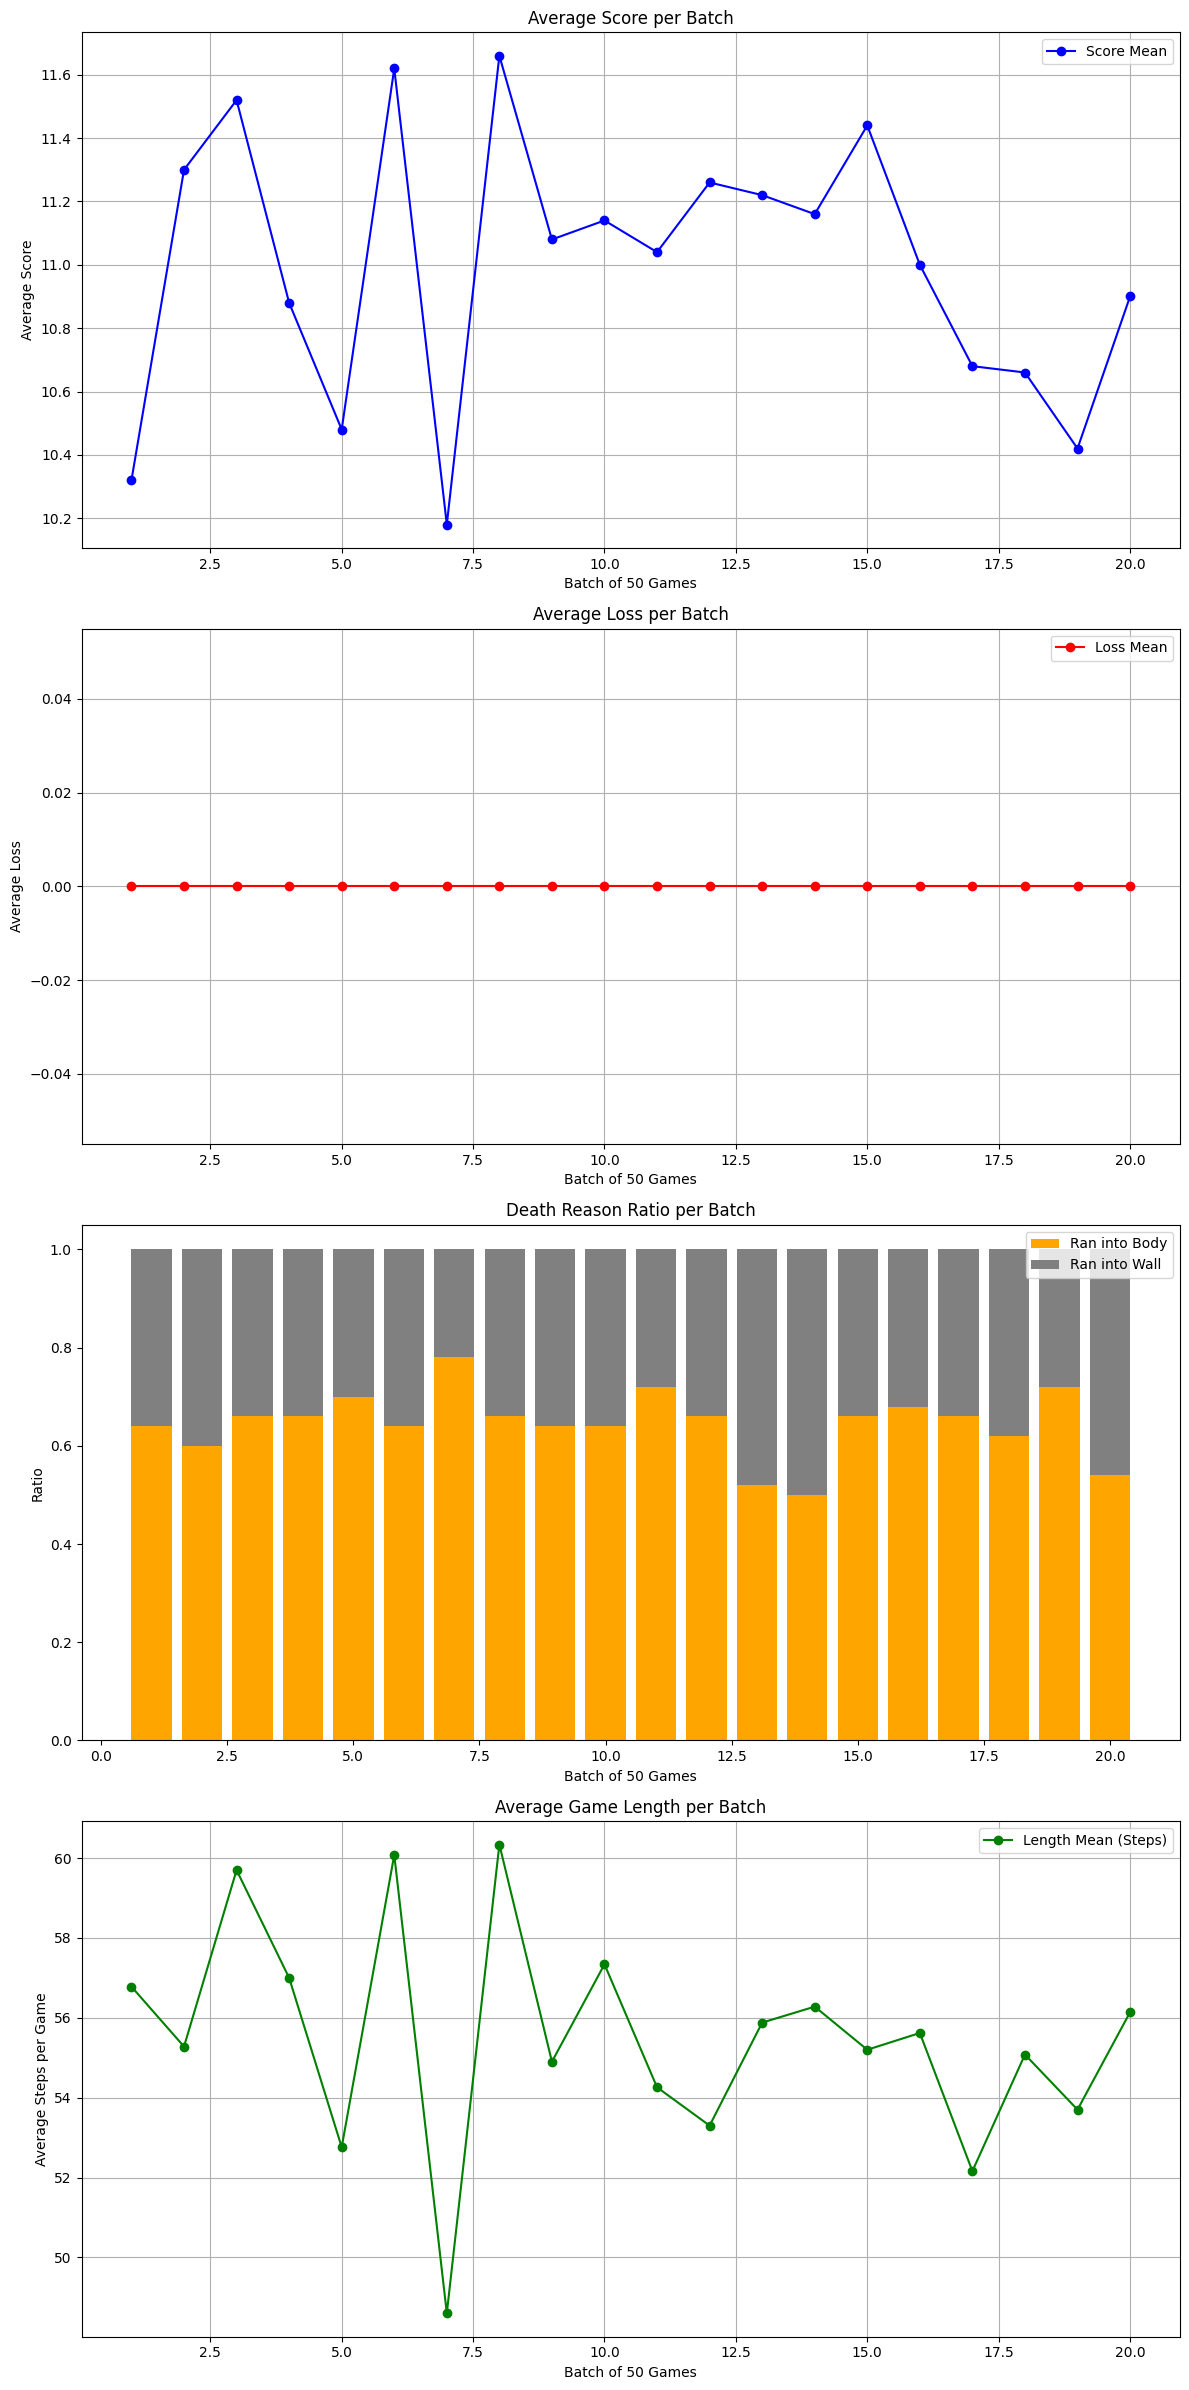

Training Games:   0%|          | 0/1001 [00:00<?, ?game/s]

_ _ _ X _
F _ _ O _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ X O _
F _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ X O _ _
F _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
X O _ _ _
F _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O O _ _ _
X _ _ _ _
_ _ _ _ _
F _ _ _ _
_ _ _ _ _
O _ _ _ _
O _ _ _ _
X _ _ _ _
F _ _ _ _
_ _ _ _ _
O _ _ _ _
O _ _ _ _
O _ _ _ _
X _ _ _ F
_ _ _ _ _
_ _ _ _ _
O _ _ _ _
O _ _ _ _
O X _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O _ _ _ _
O O X _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O O O X F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F _ _ _ _
O O O O X
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F _ _ _ X
_ O O O O
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F _ _ X O
_ _ O O O
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F _ X O O
_ _ _ O O
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F X O O O
_ _ _ _ O
_ _ _ _ _
_ _ _ _ _
F _ _ _ _
X O O O O
_ _ _ _ O
_ _ _ _ _
_ _ _ _ _
X _ _ _ _
O O O O O
_ _ _ F O
_ _ _ _ _
X _ _ _ _
O _ _ _ _
O O O O O
_ _ _ F _
_ _ _ _ _
O X _ _ _
O _ _ _ _
O O O O _
_ _ _ F _
_ _ _ _ _
O O X _ _
O _ _ _ _
O O O _ _
_ _ _ F _
_ _ _ _ _


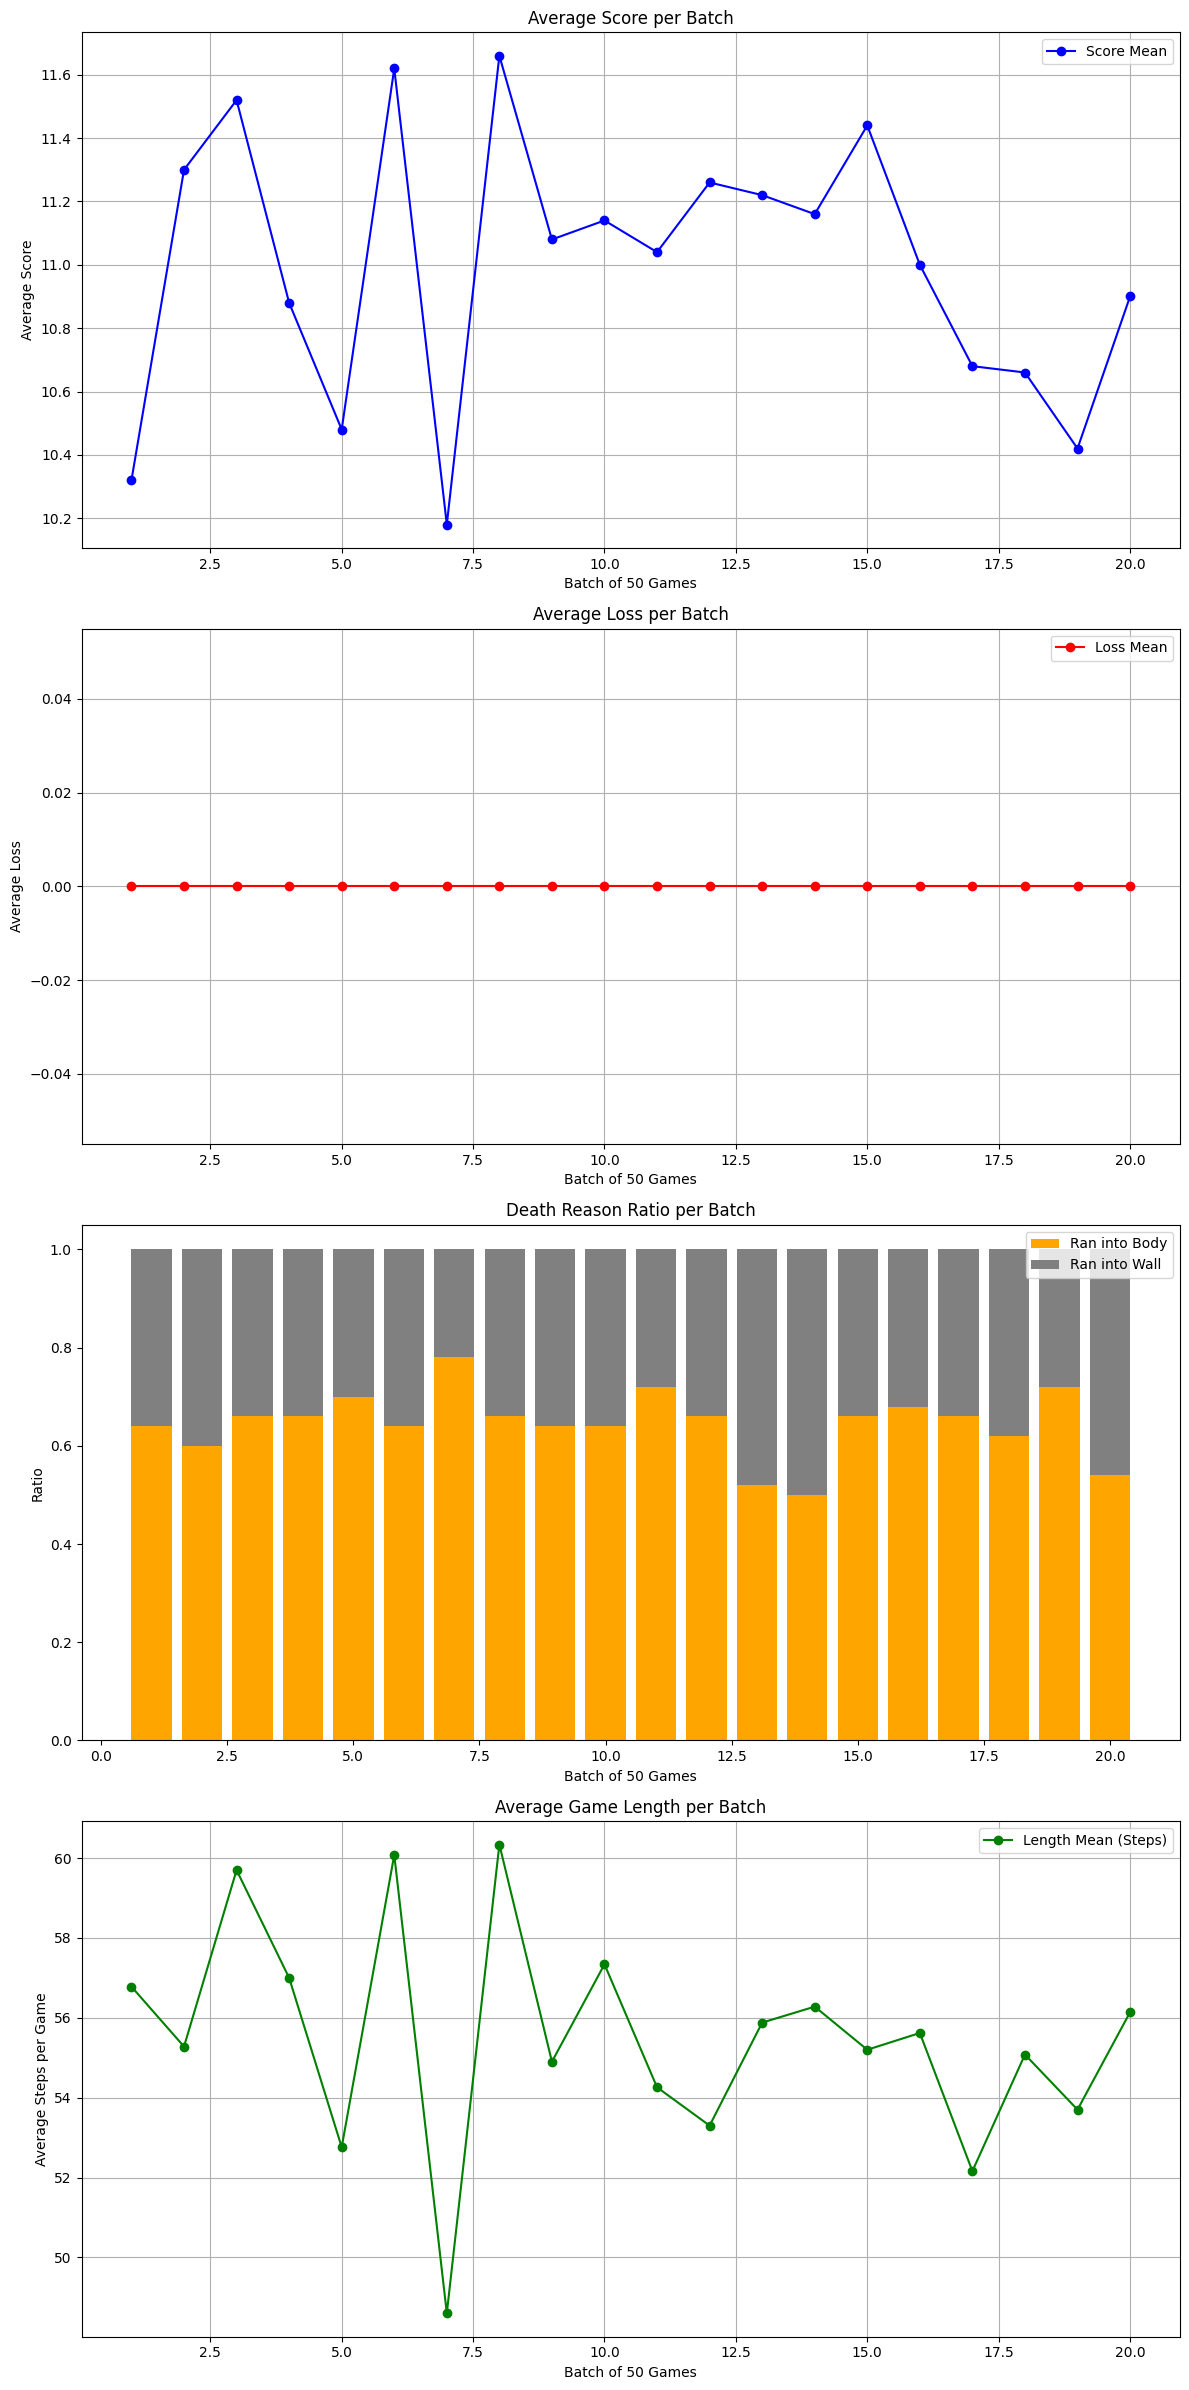

In [29]:


# Existing Hyperparameters
score_log = []
score_mean_log = []
logging_batch = 50
render_every = 200
num_games = 1000

# Tracking Variables
best_score = -1
loss_log = []
loss_mean_log = []
death_body_count = 0
death_wall_count = 0
death_ratio_log = []

# New Tracking Variables for Game Length
length_log = []
length_mean_log = []

# Create a live figure that will be updated during training.
plt.ion()
fig, axs = plt.subplots(4, 1, figsize=(12, 24))
live_display = display(fig, display_id=True)

score_line, = axs[0].plot([], [], label='Score Mean', color='blue', marker='o')
loss_line, = axs[1].plot([], [], label='Loss Mean', color='red', marker='o')
length_line, = axs[3].plot([], [], label='Length Mean (Steps)', color='green', marker='o')

axs[0].set_title('Average Score per Batch')
axs[0].set_xlabel(f'Batch of {logging_batch} Games')
axs[0].set_ylabel('Average Score')
axs[0].grid(True)
axs[0].legend()

axs[1].set_title('Average Loss per Batch')
axs[1].set_xlabel(f'Batch of {logging_batch} Games')
axs[1].set_ylabel('Average Loss')
axs[1].grid(True)
axs[1].legend()

axs[2].set_title('Death Reason Ratio per Batch')
axs[2].set_xlabel(f'Batch of {logging_batch} Games')
axs[2].set_ylabel('Ratio')

axs[3].set_title('Average Game Length per Batch')
axs[3].set_xlabel(f'Batch of {logging_batch} Games')
axs[3].set_ylabel('Average Steps per Game')
axs[3].grid(True)
axs[3].legend()


def update_live_plots():
    batches = list(range(1, len(score_mean_log) + 1))

    score_line.set_data(batches, score_mean_log)
    axs[0].relim()
    axs[0].autoscale_view()

    loss_line.set_data(batches, loss_mean_log)
    axs[1].relim()
    axs[1].autoscale_view()

    length_line.set_data(batches, length_mean_log)
    axs[3].relim()
    axs[3].autoscale_view()

    body_ratios = [r[0] for r in death_ratio_log]
    wall_ratios = [r[1] for r in death_ratio_log]
    axs[2].cla()
    axs[2].bar(batches, body_ratios, label='Ran into Body', color='orange')
    axs[2].bar(batches, wall_ratios, bottom=body_ratios, label='Ran into Wall', color='gray')
    axs[2].set_title('Death Reason Ratio per Batch')
    axs[2].set_xlabel(f'Batch of {logging_batch} Games')
    axs[2].set_ylabel('Ratio')
    axs[2].legend()

    fig.tight_layout()
    live_display.update(fig)


progress_bar = tqdm(range(num_games + 1), desc="Training Games", unit="game")

for epoch in progress_bar:
    env.reset()
    game_steps = 0
    while not env.gameover:
        state = env.get_state()
        action = agent.get_action(state.unsqueeze(0))
        next_state, reward, done = env.step(action)
        game_steps += 1
        

        if epoch % render_every == 0:
            env.render()

    score = env.snake.score

    if score > best_score and epoch > 0:
        best_score = score

    if hasattr(env, 'death_reason'):
        if env.death_reason == 'wall':
            death_wall_count += 1
        elif env.death_reason == 'body':
            death_body_count += 1

    score_log.append(score)
    length_log.append(game_steps)

    progress_bar.set_postfix({
        "score": score,
        "best": best_score if best_score >= 0 else "-",
        "steps": game_steps,
    })

    # Logging batch updates.
    if (epoch + 1) % logging_batch == 0:
        mean = sum(score_log) / len(score_log)
        score_mean_log.append(mean)
        score_log = []

        if loss_log:
            loss_mean = sum(loss_log) / len(loss_log)
            loss_mean_log.append(loss_mean)
            loss_log = []
        else:
            loss_mean_log.append(0)

        if length_log:
            length_mean = sum(length_log) / len(length_log)
            length_mean_log.append(length_mean)
            length_log = []
        else:
            length_mean_log.append(0)

        total_deaths = death_body_count + death_wall_count
        if total_deaths > 0:
            death_ratio_log.append((death_body_count / total_deaths, death_wall_count / total_deaths))
        else:
            death_ratio_log.append((0, 0))

        death_body_count = 0
        death_wall_count = 0

        update_live_plots()

        tqdm.write(
            f"Batch {epoch + 1} | Avg Score: {score_mean_log[-1]:.3f} | "
            f"Avg Loss: {loss_mean_log[-1]:.4f} | Avg Length: {length_mean_log[-1]:.1f}"
        )

# Keep final figure visible after training ends.
plt.ioff()
fig.tight_layout()
live_display.update(fig)
plt.show()

In [30]:
# snake_agent2 testing, 1 game

num_games = 1
snake_agent2.epsilon = 0

for epoch in range(num_games):
    score = snake_env1.snake.score
    snake_env1.reset()
    print(f"GAME NUMBER {epoch}")

    while not snake_env1.gameover:
        state = snake_env1.get_state()
        #state = state.flatten()
        state = state.unsqueeze(0) 

        action = snake_agent2.get_action(state)
        next_state, reward, done = snake_env1.step(action)
        snake_env1.render()

    print(f"score for game {epoch}: {score}")

NameError: name 'snake_agent2' is not defined

Add to the input state the place of the tail, this may improve the learning as it knows where the tail is going, (d_model 4->5 + update environment)

In [52]:
env=snake_environment(5,5)

In [71]:

env.step(1)
env.render()

_ O O _ F
_ O X _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
